Current folder:
C:\Users\user\Downloads\DATASET IR
Dataset found at:
C:\Users\user\Downloads\DATASET IR\cleaned_movie.csv
Dataset shape: (1000, 8)

Column names:
['Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Released_Year  1000 non-null   object 
 1   Certificate    1000 non-null   object 
 2   Runtime        1000 non-null   object 
 3   Genre          1000 non-null   object 
 4   IMDB_Rating    1000 non-null   float64
 5   Meta_score     1000 non-null   float64
 6   No_of_Votes    1000 non-null   int64  
 7   Gross          1000 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 62.6+ KB

Summary statistics:
Dataset shape after cleaning: (999, 9)
Input feature shape: (999, 7)
Target shape

,Released_Year,Runtime_min,Certificate,Genre,Meta_score,No_of_Votes,Gross
0,1994.0,142.0,A,Drama,80.0,2343110,28341469.0
1,1972.0,175.0,A,"Crime, Drama",100.0,1620367,134966411.0
2,2008.0,152.0,UA,"Action, Crime, Drama",84.0,2303232,534858444.0
3,1974.0,202.0,A,"Crime, Drama",90.0,1129952,57300000.0
4,1957.0,96.0,U,"Crime, Drama",96.0,689845,4360000.0



Target variable:


0    9.3
1    9.2
2    9.0
3    9.0
4    9.0
Name: IMDB_Rating, dtype: float64

Training set shape: (699, 7)
Validation set shape: (150, 7)
Testing set shape: (150, 7)
Processed training shape: (699, 193)
Processed validation shape: (150, 193)
Processed testing shape: (150, 193)
Boosting stages: 10 | Train RMSE: 0.2313 | Validation RMSE: 0.2584 | Validation MAE: 0.2066 | Validation R2: 0.1473
Boosting stages: 20 | Train RMSE: 0.2064 | Validation RMSE: 0.245 | Validation MAE: 0.1968 | Validation R2: 0.2335
Boosting stages: 50 | Train RMSE: 0.1706 | Validation RMSE: 0.2194 | Validation MAE: 0.1774 | Validation R2: 0.3856
Boosting stages: 100 | Train RMSE: 0.1512 | Validation RMSE: 0.2115 | Validation MAE: 0.1705 | Validation R2: 0.4286
Boosting stages: 150 | Train RMSE: 0.1398 | Validation RMSE: 0.2082 | Validation MAE: 0.1664 | Validation R2: 0.4463
Boosting stages: 200 | Train RMSE: 0.1326 | Validation RMSE: 0.2068 | Validation MAE: 0.1647 | Validation R2: 0.4541
Boosting stages: 300 | Train RMSE: 0.1222 | Validation RMSE: 0.2064 | Validation MAE: 0.1642 | Validat

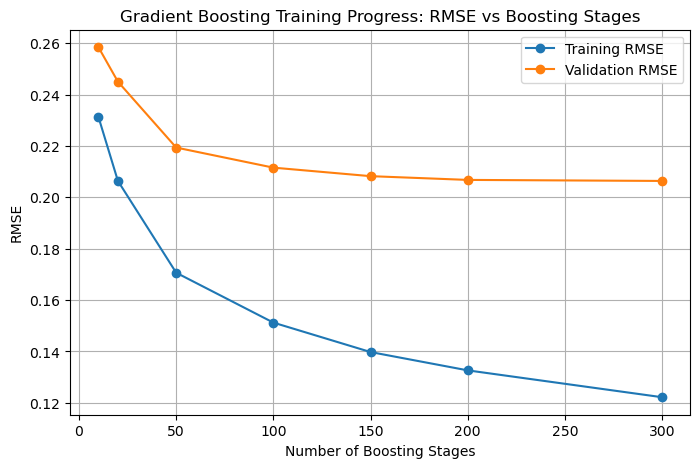

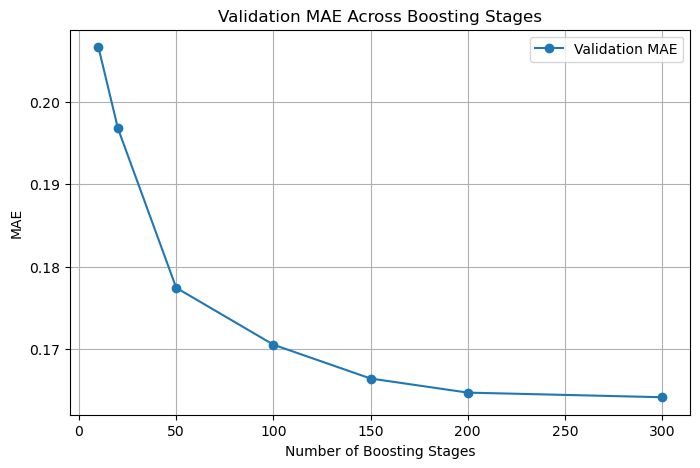

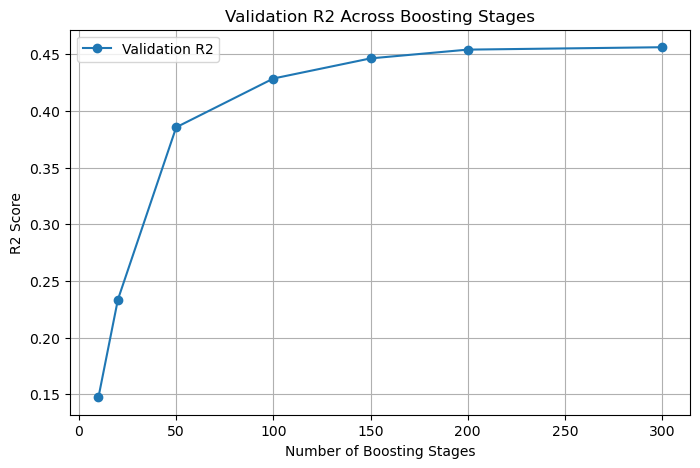

Final Gradient Boosting Test Metrics
------------------------------------
Best number of boosting stages: 300
Test RMSE: 0.1907
Test MAE: 0.1477
Test R2: 0.4701


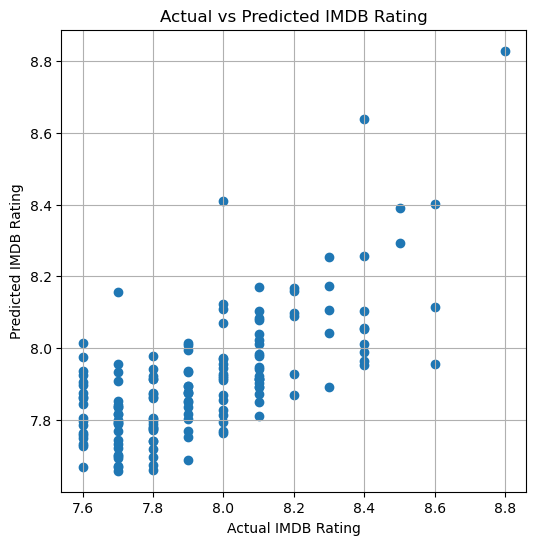

Milestone 3 Training Summary
----------------------------
Problem type: Supervised regression
Target variable: IMDB_Rating
Model: Gradient Boosting Regressor
Training progress method: Increasing boosting stages
Boosting stages tested: [10, 20, 50, 100, 150, 200, 300]
Learning rate: 0.05
Max depth: 3

Best Validation Result:
Best boosting stages: 300
Best Validation RMSE: 0.2064
Validation MAE: 0.1642
Validation R2: 0.4562

Final Test Result:
Test RMSE: 0.1907
Test MAE: 0.1477
Test R2: 0.4701


In [2]:
# ============================================================
# KD34403 Machine Learning for Data Science
# Milestone 3: The Training Loop
# Model: Gradient Boosting Regressor
# Task: Predict IMDB_Rating
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# ============================================================
# 1. Load dataset
# ============================================================

print("Current folder:")
print(os.getcwd())

csv_path = None

# Search for cleaned_movie.csv in current folder and subfolders
for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file == "cleaned_movie.csv":
            csv_path = os.path.join(root, file)
            break
    if csv_path is not None:
        break

if csv_path is None:
    raise FileNotFoundError(
        "cleaned_movie.csv was not found. Make sure it is inside your JupyterLab folder."
    )

print("Dataset found at:")
print(csv_path)

df = pd.read_csv(csv_path)

df.head()
# ============================================================
# 2. Check dataset
# ============================================================

df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
df.describe()

# ============================================================
# 3. Data preparation
# ============================================================

# Convert Released_Year to numeric
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

# Convert Runtime from text, for example "142 min", into numerical minutes
df["Runtime_min"] = df["Runtime"].astype(str).str.extract(r"(\d+)").astype(float)

# Convert Gross to numeric
df["Gross"] = df["Gross"].astype(str).str.replace(",", "", regex=False)
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

# Convert No_of_Votes to numeric
df["No_of_Votes"] = df["No_of_Votes"].astype(str).str.replace(",", "", regex=False)
df["No_of_Votes"] = pd.to_numeric(df["No_of_Votes"], errors="coerce")

# Convert Meta_score and IMDB_Rating to numeric
df["Meta_score"] = pd.to_numeric(df["Meta_score"], errors="coerce")
df["IMDB_Rating"] = pd.to_numeric(df["IMDB_Rating"], errors="coerce")

# Remove rows with missing important values
df = df.dropna(subset=[
    "Released_Year",
    "Runtime_min",
    "Certificate",
    "Genre",
    "Meta_score",
    "No_of_Votes",
    "Gross",
    "IMDB_Rating"
])

print("Dataset shape after cleaning:", df.shape)

df.head()

# ============================================================
# 4. Define input features and target variable
# ============================================================

X = df[
    [
        "Released_Year",
        "Runtime_min",
        "Certificate",
        "Genre",
        "Meta_score",
        "No_of_Votes",
        "Gross"
    ]
]

y = df["IMDB_Rating"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput features:")
display(X.head())

print("\nTarget variable:")
display(y.head())

# ============================================================
# 5. Train-validation-test split
# 70% training, 15% validation, 15% testing
# ============================================================

# First split: 85% train+validation, 15% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

# Second split: from 85%, create about 70% training and 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Testing set shape:", X_test.shape)
# ============================================================
# 6. Preprocessing
# Numerical features: StandardScaler
# Categorical features: OneHotEncoder
# ============================================================

numeric_features = [
    "Released_Year",
    "Runtime_min",
    "Meta_score",
    "No_of_Votes",
    "Gross"
]

categorical_features = [
    "Certificate",
    "Genre"
]

# OneHotEncoder syntax depends on sklearn version
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply same preprocessing to validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
# ============================================================
# 7. Gradient Boosting training progress
# Demonstrate progress by increasing boosting stages / trees
# ============================================================

estimator_values = [10, 20, 50, 100, 150, 200, 300]

history = []

for n_estimators in estimator_values:
    
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    
    # Train model
    model.fit(X_train_processed, y_train)
    
    # Predict training and validation values
    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    
    # Calculate training metrics
    train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)
    
    # Calculate validation metrics
    val_rmse = mean_squared_error(y_val, val_pred) ** 0.5
    val_mae = mean_absolute_error(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)
    
    # Store result
    history.append({
        "Boosting Stages": n_estimators,
        "Train RMSE": train_rmse,
        "Train MAE": train_mae,
        "Train R2": train_r2,
        "Validation RMSE": val_rmse,
        "Validation MAE": val_mae,
        "Validation R2": val_r2
    })
    
    print(
        "Boosting stages:", n_estimators,
        "| Train RMSE:", round(train_rmse, 4),
        "| Validation RMSE:", round(val_rmse, 4),
        "| Validation MAE:", round(val_mae, 4),
        "| Validation R2:", round(val_r2, 4)
    )

history_df = pd.DataFrame(history)

history_df
# ============================================================
# 8. Find best model based on lowest validation RMSE
# ============================================================

best_result = history_df.loc[history_df["Validation RMSE"].idxmin()]

print("Best Gradient Boosting Result")
print("-----------------------------")
print(best_result)
# ============================================================
# 9. Plot training progress
# Training RMSE vs Validation RMSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Boosting Stages"],
    history_df["Train RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    history_df["Boosting Stages"],
    history_df["Validation RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("RMSE")
plt.title("Gradient Boosting Training Progress: RMSE vs Boosting Stages")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 10. Plot validation MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Boosting Stages"],
    history_df["Validation MAE"],
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("MAE")
plt.title("Validation MAE Across Boosting Stages")
plt.legend()
plt.grid(True)
plt.show()
# ============================================================
# 11. Plot validation R2
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Boosting Stages"],
    history_df["Validation R2"],
    marker="o",
    label="Validation R2"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("R2 Score")
plt.title("Validation R2 Across Boosting Stages")
plt.legend()
plt.grid(True)
plt.show()
# ============================================================
# 12. Final test evaluation using best number of boosting stages
# ============================================================

best_n_estimators = int(best_result["Boosting Stages"])

final_model = GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_model.fit(X_train_processed, y_train)

test_pred = final_model.predict(X_test_processed)

test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print("Final Gradient Boosting Test Metrics")
print("------------------------------------")
print("Best number of boosting stages:", best_n_estimators)
print("Test RMSE:", round(test_rmse, 4))
print("Test MAE:", round(test_mae, 4))
print("Test R2:", round(test_r2, 4))

# ============================================================
# 13. Compare actual and predicted IMDB ratings
# ============================================================

results_df = pd.DataFrame({
    "Actual IMDB Rating": y_test.values,
    "Predicted IMDB Rating": test_pred,
    "Absolute Error": abs(y_test.values - test_pred)
})

results_df.head(10)
# ============================================================
# 14. Plot actual vs predicted IMDB ratings
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    results_df["Actual IMDB Rating"],
    results_df["Predicted IMDB Rating"]
)

plt.xlabel("Actual IMDB Rating")
plt.ylabel("Predicted IMDB Rating")
plt.title("Actual vs Predicted IMDB Rating")
plt.grid(True)
plt.show()
# ============================================================
# 15. Final Milestone 3 summary
# ============================================================

print("Milestone 3 Training Summary")
print("----------------------------")
print("Problem type: Supervised regression")
print("Target variable: IMDB_Rating")
print("Model: Gradient Boosting Regressor")
print("Training progress method: Increasing boosting stages")
print("Boosting stages tested:", estimator_values)
print("Learning rate: 0.05")
print("Max depth:", 3)

print("\nBest Validation Result:")
print("Best boosting stages:", best_n_estimators)
print("Best Validation RMSE:", round(best_result["Validation RMSE"], 4))
print("Validation MAE:", round(best_result["Validation MAE"], 4))
print("Validation R2:", round(best_result["Validation R2"], 4))

print("\nFinal Test Result:")
print("Test RMSE:", round(test_rmse, 4))
print("Test MAE:", round(test_mae, 4))
print("Test R2:", round(test_r2, 4))

Current folder:
C:\Users\user\Downloads\DATASET IR
Dataset found at:
C:\Users\user\Downloads\DATASET IR\cleaned_movie.csv
Dataset shape: (1000, 8)

Column names:
['Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Released_Year  1000 non-null   object 
 1   Certificate    1000 non-null   object 
 2   Runtime        1000 non-null   object 
 3   Genre          1000 non-null   object 
 4   IMDB_Rating    1000 non-null   float64
 5   Meta_score     1000 non-null   float64
 6   No_of_Votes    1000 non-null   int64  
 7   Gross          1000 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 62.6+ KB

Summary statistics:
Dataset shape after cleaning: (999, 9)
Input feature shape: (999, 7)
Target shape

,Released_Year,Runtime_min,Certificate,Genre,Meta_score,No_of_Votes,Gross
0,1994.0,142.0,A,Drama,80.0,2343110,28341469.0
1,1972.0,175.0,A,"Crime, Drama",100.0,1620367,134966411.0
2,2008.0,152.0,UA,"Action, Crime, Drama",84.0,2303232,534858444.0
3,1974.0,202.0,A,"Crime, Drama",90.0,1129952,57300000.0
4,1957.0,96.0,U,"Crime, Drama",96.0,689845,4360000.0



Target variable:


0    9.3
1    9.2
2    9.0
3    9.0
4    9.0
Name: IMDB_Rating, dtype: float64

Training set shape: (699, 7)
Validation set shape: (150, 7)
Testing set shape: (150, 7)
Processed training shape: (699, 193)
Processed validation shape: (150, 193)
Processed testing shape: (150, 193)
Boosting stages: 10 | Train RMSE: 0.2313 | Validation RMSE: 0.2584 | Validation MAE: 0.2066 | Validation R2: 0.1473
Boosting stages: 20 | Train RMSE: 0.2064 | Validation RMSE: 0.245 | Validation MAE: 0.1968 | Validation R2: 0.2335
Boosting stages: 50 | Train RMSE: 0.1706 | Validation RMSE: 0.2194 | Validation MAE: 0.1774 | Validation R2: 0.3856
Boosting stages: 100 | Train RMSE: 0.1512 | Validation RMSE: 0.2115 | Validation MAE: 0.1705 | Validation R2: 0.4286
Boosting stages: 150 | Train RMSE: 0.1398 | Validation RMSE: 0.2082 | Validation MAE: 0.1664 | Validation R2: 0.4463
Boosting stages: 200 | Train RMSE: 0.1326 | Validation RMSE: 0.2068 | Validation MAE: 0.1647 | Validation R2: 0.4541
Boosting stages: 300 | Train RMSE: 0.1222 | Validation RMSE: 0.2064 | Validation MAE: 0.1642 | Validat

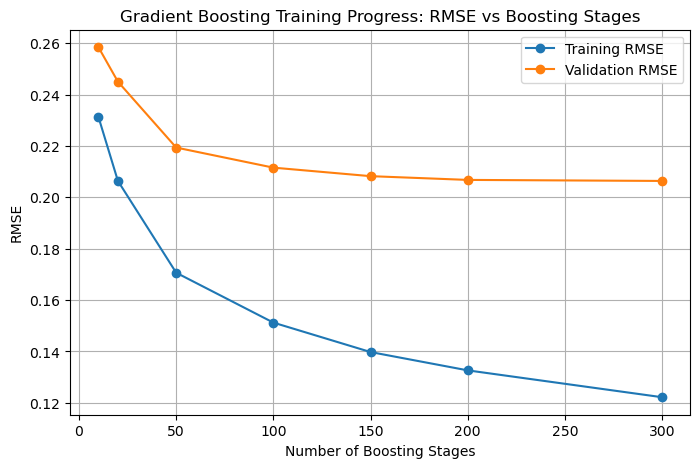

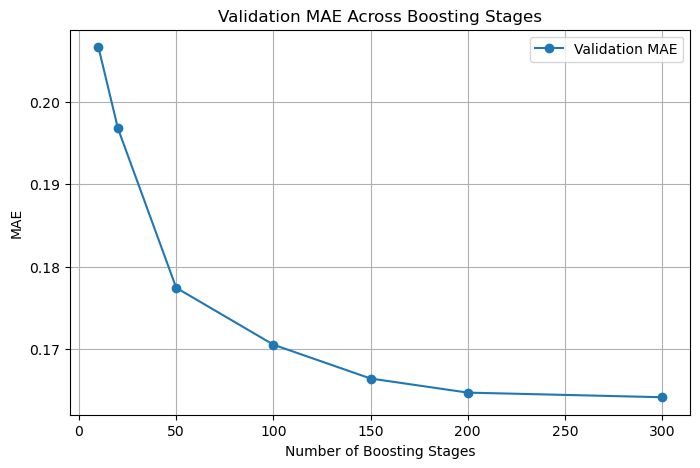

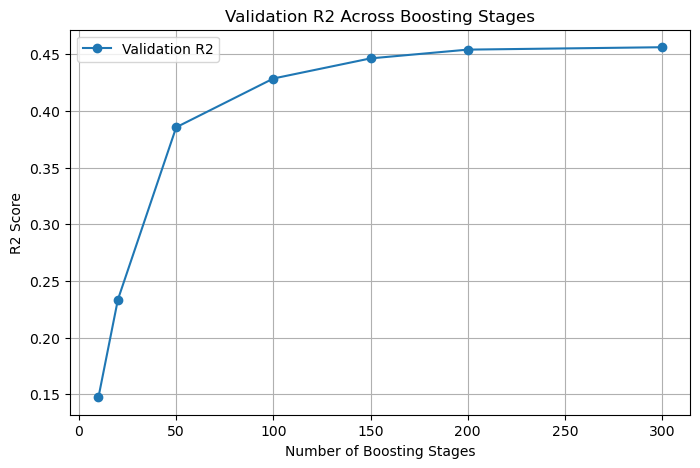

Final Gradient Boosting Test Metrics
------------------------------------
Best number of boosting stages: 300
Test RMSE: 0.1907
Test MAE: 0.1477
Test R2: 0.4701


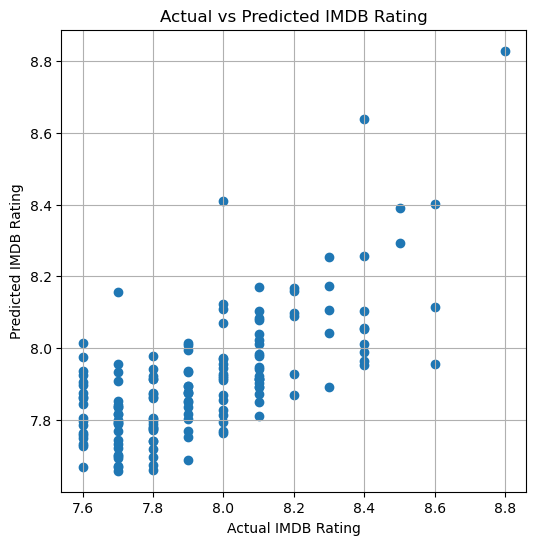

Milestone 3 Training Summary
----------------------------
Problem type: Supervised regression
Target variable: IMDB_Rating
Model: Gradient Boosting Regressor
Training progress method: Increasing boosting stages
Boosting stages tested: [10, 20, 50, 100, 150, 200, 300]
Learning rate: 0.05
Max depth: 3

Best Validation Result:
Best boosting stages: 300
Best Validation RMSE: 0.2064
Validation MAE: 0.1642
Validation R2: 0.4562

Final Test Result:
Test RMSE: 0.1907
Test MAE: 0.1477
Test R2: 0.4701


In [2]:
# ============================================================
# KD34403 Machine Learning for Data Science
# Milestone 3: The Training Loop
# Model: Gradient Boosting Regressor
# Task: Predict IMDB_Rating
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# ============================================================
# 1. Load dataset
# ============================================================

print("Current folder:")
print(os.getcwd())

csv_path = None

# Search for cleaned_movie.csv in current folder and subfolders
for root, dirs, files in os.walk(os.getcwd()):
    for file in files:
        if file == "cleaned_movie.csv":
            csv_path = os.path.join(root, file)
            break
    if csv_path is not None:
        break

if csv_path is None:
    raise FileNotFoundError(
        "cleaned_movie.csv was not found. Make sure it is inside your JupyterLab folder."
    )

print("Dataset found at:")
print(csv_path)

df = pd.read_csv(csv_path)

df.head()
# ============================================================
# 2. Check dataset
# ============================================================

df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
df.describe()

# ============================================================
# 3. Data preparation
# ============================================================

# Convert Released_Year to numeric
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

# Convert Runtime from text, for example "142 min", into numerical minutes
df["Runtime_min"] = df["Runtime"].astype(str).str.extract(r"(\d+)").astype(float)

# Convert Gross to numeric
df["Gross"] = df["Gross"].astype(str).str.replace(",", "", regex=False)
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

# Convert No_of_Votes to numeric
df["No_of_Votes"] = df["No_of_Votes"].astype(str).str.replace(",", "", regex=False)
df["No_of_Votes"] = pd.to_numeric(df["No_of_Votes"], errors="coerce")

# Convert Meta_score and IMDB_Rating to numeric
df["Meta_score"] = pd.to_numeric(df["Meta_score"], errors="coerce")
df["IMDB_Rating"] = pd.to_numeric(df["IMDB_Rating"], errors="coerce")

# Remove rows with missing important values
df = df.dropna(subset=[
    "Released_Year",
    "Runtime_min",
    "Certificate",
    "Genre",
    "Meta_score",
    "No_of_Votes",
    "Gross",
    "IMDB_Rating"
])

print("Dataset shape after cleaning:", df.shape)

df.head()

# ============================================================
# 4. Define input features and target variable
# ============================================================

X = df[
    [
        "Released_Year",
        "Runtime_min",
        "Certificate",
        "Genre",
        "Meta_score",
        "No_of_Votes",
        "Gross"
    ]
]

y = df["IMDB_Rating"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput features:")
display(X.head())

print("\nTarget variable:")
display(y.head())

# ============================================================
# 5. Train-validation-test split
# 70% training, 15% validation, 15% testing
# ============================================================

# First split: 85% train+validation, 15% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

# Second split: from 85%, create about 70% training and 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1765,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Testing set shape:", X_test.shape)
# ============================================================
# 6. Preprocessing
# Numerical features: StandardScaler
# Categorical features: OneHotEncoder
# ============================================================

numeric_features = [
    "Released_Year",
    "Runtime_min",
    "Meta_score",
    "No_of_Votes",
    "Gross"
]

categorical_features = [
    "Certificate",
    "Genre"
]

# OneHotEncoder syntax depends on sklearn version
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply same preprocessing to validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
# ============================================================
# 7. Gradient Boosting training progress
# Demonstrate progress by increasing boosting stages / trees
# ============================================================

estimator_values = [10, 20, 50, 100, 150, 200, 300]

history = []

for n_estimators in estimator_values:
    
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    
    # Train model
    model.fit(X_train_processed, y_train)
    
    # Predict training and validation values
    train_pred = model.predict(X_train_processed)
    val_pred = model.predict(X_val_processed)
    
    # Calculate training metrics
    train_rmse = mean_squared_error(y_train, train_pred) ** 0.5
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)
    
    # Calculate validation metrics
    val_rmse = mean_squared_error(y_val, val_pred) ** 0.5
    val_mae = mean_absolute_error(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)
    
    # Store result
    history.append({
        "Boosting Stages": n_estimators,
        "Train RMSE": train_rmse,
        "Train MAE": train_mae,
        "Train R2": train_r2,
        "Validation RMSE": val_rmse,
        "Validation MAE": val_mae,
        "Validation R2": val_r2
    })
    
    print(
        "Boosting stages:", n_estimators,
        "| Train RMSE:", round(train_rmse, 4),
        "| Validation RMSE:", round(val_rmse, 4),
        "| Validation MAE:", round(val_mae, 4),
        "| Validation R2:", round(val_r2, 4)
    )

history_df = pd.DataFrame(history)

history_df
# ============================================================
# 8. Find best model based on lowest validation RMSE
# ============================================================

best_result = history_df.loc[history_df["Validation RMSE"].idxmin()]

print("Best Gradient Boosting Result")
print("-----------------------------")
print(best_result)
# ============================================================
# 9. Plot training progress
# Training RMSE vs Validation RMSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Boosting Stages"],
    history_df["Train RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    history_df["Boosting Stages"],
    history_df["Validation RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("RMSE")
plt.title("Gradient Boosting Training Progress: RMSE vs Boosting Stages")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 10. Plot validation MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Boosting Stages"],
    history_df["Validation MAE"],
    marker="o",
    label="Validation MAE"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("MAE")
plt.title("Validation MAE Across Boosting Stages")
plt.legend()
plt.grid(True)
plt.show()
# ============================================================
# 11. Plot validation R2
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["Boosting Stages"],
    history_df["Validation R2"],
    marker="o",
    label="Validation R2"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("R2 Score")
plt.title("Validation R2 Across Boosting Stages")
plt.legend()
plt.grid(True)
plt.show()
# ============================================================
# 12. Final test evaluation using best number of boosting stages
# ============================================================

best_n_estimators = int(best_result["Boosting Stages"])

final_model = GradientBoostingRegressor(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_model.fit(X_train_processed, y_train)

test_pred = final_model.predict(X_test_processed)

test_rmse = mean_squared_error(y_test, test_pred) ** 0.5
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

print("Final Gradient Boosting Test Metrics")
print("------------------------------------")
print("Best number of boosting stages:", best_n_estimators)
print("Test RMSE:", round(test_rmse, 4))
print("Test MAE:", round(test_mae, 4))
print("Test R2:", round(test_r2, 4))

# ============================================================
# 13. Compare actual and predicted IMDB ratings
# ============================================================

results_df = pd.DataFrame({
    "Actual IMDB Rating": y_test.values,
    "Predicted IMDB Rating": test_pred,
    "Absolute Error": abs(y_test.values - test_pred)
})

results_df.head(10)
# ============================================================
# 14. Plot actual vs predicted IMDB ratings
# ============================================================

plt.figure(figsize=(6, 6))

plt.scatter(
    results_df["Actual IMDB Rating"],
    results_df["Predicted IMDB Rating"]
)

plt.xlabel("Actual IMDB Rating")
plt.ylabel("Predicted IMDB Rating")
plt.title("Actual vs Predicted IMDB Rating")
plt.grid(True)
plt.show()
# ============================================================
# 15. Final Milestone 3 summary
# ============================================================

print("Milestone 3 Training Summary")
print("----------------------------")
print("Problem type: Supervised regression")
print("Target variable: IMDB_Rating")
print("Model: Gradient Boosting Regressor")
print("Training progress method: Increasing boosting stages")
print("Boosting stages tested:", estimator_values)
print("Learning rate: 0.05")
print("Max depth:", 3)

print("\nBest Validation Result:")
print("Best boosting stages:", best_n_estimators)
print("Best Validation RMSE:", round(best_result["Validation RMSE"], 4))
print("Validation MAE:", round(best_result["Validation MAE"], 4))
print("Validation R2:", round(best_result["Validation R2"], 4))

print("\nFinal Test Result:")
print("Test RMSE:", round(test_rmse, 4))
print("Test MAE:", round(test_mae, 4))
print("Test R2:", round(test_r2, 4))